# Outlier investigation — `d_fit · S` (Task 2)

Companion to `20260609_06_minimal_model_d_fit.ipynb`. There, the minimal-model
byproduct-consumption rate `d` is fitted so its Turing dispersion peak matches a sampled
complex community, and `1/d_fit` is plotted against the number of surviving strains `S`.
The symmetric-loop theory predicts the points scatter around `1/d_fit = S`
(`d_fit · S ~ 1`). Most do, but ~13/100 sit far **above** the line — anomalously large
`1/d_fit` (tiny fitted `d`) for their `S`.

**Goal:** determine what is distinct about these outliers.

We reuse the exact sampler and helpers from notebook 06 (parameters fixed: `linflux=1.0`,
`K=30`, `N=M=20`, `B=3`; seed 0; 100 repeats), but retain the full community state for each
repeat so we can dissect the cross-feeding structure of the outliers.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats as scistats
from scipy.stats import binom as binom_dist
from scipy.optimize import brentq

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                             'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

colorTable = {}
colorTable['k'] = [0, 0, 0]
colorTable['g'] = [27/255, 158/255, 119/255]
colorTable['o'] = [217/255, 95/255, 2/255]

from ssmc.sampling import JansSampler3, Dirac
from ssmc.linstab import scan_k, classify
from ssmc.solver import solve_steady_state
from ssmc.plotting import plot_dispersion
from ssmc.minimal_model import MMParams, mmp_to_smicrm, mm_get_nospace_sol

## Parameters and sampler

*(copied verbatim from notebook 06, cell 4)*

In [3]:
N, M, B = 20, 20, 3
K_FIXED   = 30.0
LINFLUX   = 1.0

# Wavenumber grid for full model (1000 pts is sufficient, much faster than 10000)
lsks = np.logspace(-6, 6, 1000)

# Coarser grid for the minimal-model optimisation (fast 3x3 eigvals)
lsks_mm = np.logspace(-6, 6, 1000)

# Relative abundance cutoff for 'surviving' strains
STRAIN_CUTOFF_REL = 1e-3

def base10_lognormal(b10m, b10std):
    """Port of Julia base10_lognormal: LogNormal in base-10 log space."""
    return scistats.lognorm(s=b10std * np.log(10), scale=np.exp(b10m * np.log(10)))

sampler = JansSampler3(
    Ns=N, Nr=M,
    m=base10_lognormal(0.0, 0.001),   # ≈ Dirac(1.0)
    r=Dirac(1.0),
    num_influx_resources=1,
    K=Dirac(K_FIXED),
    prob_eating=B / M,                 # 0.15
    prob_eating_influx=1.0,
    num_byproducts=binom_dist(n=M, p=B / M),
    c=base10_lognormal(0.0, 0.001),
    l=Dirac(0.0),
    cinflux=base10_lognormal(0.0, 0.001),
    linflux=Dirac(LINFLUX),
    Ds=Dirac(1e-12),
    Dr=Dirac(1.0),
    Drinflux=Dirac(1.0),
)

## Helper functions

*(copied verbatim from notebook 06, cell 6)*

In [4]:
def get_unstable_community(sampler, rng, max_tries=50, t_max=2e3):
    """Sample until a Turing-unstable steady state is found (code 2 or 12).
    Returns (sparams, u_ss, linstab_result) or (None, None, None) on failure.
    """
    for _ in range(max_tries):
        sparams = sampler(rng)
        micrm = sparams.micrm
        Ns, Nr = micrm.Ns, micrm.Nr
        u0 = np.concatenate([np.ones(Ns), np.zeros(Nr)])
        u_ss, ok = solve_steady_state(micrm, u0, t_max=t_max,
                                      rtol=1e-9, atol=1e-11, ss_tol=1e-8)
        if not ok or np.max(u_ss[:Ns]) < 1e-6:
            continue
        res = scan_k(sparams, u_ss, lsks)
        if classify(res) == 'unstable':
            return sparams, u_ss, res
    return None, None, None


def count_surviving_strains(u_ss, Ns, rel_cutoff=STRAIN_CUTOFF_REL):
    """Number of strains above rel_cutoff * max_strain."""
    strains = u_ss[:Ns]
    threshold = rel_cutoff * np.max(strains)
    return int(np.sum(strains > threshold))


def mm_scan(d):
    """Run scan_k for the minimal model at byproduct consumption rate d."""
    mmp = MMParams(K=K_FIXED, m=1.0, c=1.0, l=LINFLUX, d=d)
    smmp = mmp_to_smicrm(mmp, DN=1e-12, DI=1.0, DR=1.0)
    sols = [s for s in mm_get_nospace_sol(mmp) if s[0] > 1e-8]
    if not sols:
        return None
    ss = max(sols, key=lambda s: s[0])   # largest-N branch
    return scan_k(smmp, ss, lsks_mm)


def mm_peak_height(d):
    result = mm_scan(d)
    return result.max_mrl if result is not None else np.nan


def fit_d(target_peak, d_lo=0.055, d_hi=200.0):
    """Find d such that mm_peak_height(d) == target_peak using Brent's method."""
    f_lo = mm_peak_height(d_lo) - target_peak
    f_hi = mm_peak_height(d_hi) - target_peak
    if np.isnan(f_lo) or np.isnan(f_hi):
        return np.nan
    if f_lo * f_hi > 0:
        return np.nan
    try:
        return brentq(lambda d: mm_peak_height(d) - target_peak,
                      d_lo, d_hi, xtol=1e-4, rtol=1e-3)
    except ValueError:
        return np.nan

## Sweep with full state retention

Same sweep as notebook 06 (seed 0, 100 repeats), but we keep the steady state `u_ss`,
the linear-stability result `res`, and the parameter object `sparams` for every repeat so
the cross-feeding structure can be dissected later.

In [5]:
N_REPEATS = 100
rng = np.random.default_rng(0)

records = []
for i in range(N_REPEATS):
    sparams, u_ss, res = get_unstable_community(sampler, rng)
    if sparams is None:
        print(f"[{i+1:3d}/{N_REPEATS}] no unstable community found")
        continue

    S = count_surviving_strains(u_ss, sparams.Ns)
    d_val = fit_d(res.max_mrl)
    k_mm = np.nan
    peak_mm = np.nan
    if not np.isnan(d_val):
        res_mm = mm_scan(d_val)
        if res_mm is not None:
            k_mm = res_mm.max_k
            peak_mm = res_mm.max_mrl

    records.append(dict(
        rep=i, S=S, d_fit=d_val, inv_d=(1.0 / d_val if not np.isnan(d_val) else np.nan),
        peak_full=res.max_mrl, k_full=res.max_k, peak_mm=peak_mm, k_mm=k_mm,
        u_ss=u_ss.copy(), sparams=sparams, res=res,
    ))

    if (i + 1) % 10 == 0:
        print(f"[{i+1:3d}/{N_REPEATS}]  S={S:2d}  peak={res.max_mrl:.5f}  "
              f"d_fit={d_val:.4f}  1/d={1.0/d_val:.2f}")

print(f"\nCollected {len(records)} unstable communities.")

[ 10/100]  S= 4  peak=0.00090  d_fit=0.3782  1/d=2.64


[ 20/100]  S= 4  peak=0.00130  d_fit=0.2767  1/d=3.61


[ 30/100]  S= 6  peak=0.00122  d_fit=0.2917  1/d=3.43


[ 40/100]  S= 5  peak=0.00174  d_fit=0.2193  1/d=4.56


[ 50/100]  S= 1  peak=0.00031  d_fit=1.0110  1/d=0.99


[ 60/100]  S= 4  peak=0.00139  d_fit=0.2623  1/d=3.81


[ 70/100]  S= 6  peak=0.01154  d_fit=0.0723  1/d=13.84


[ 80/100]  S= 8  peak=0.00139  d_fit=0.2617  1/d=3.82


[ 90/100]  S= 1  peak=0.00031  d_fit=0.9921  1/d=1.01


[100/100]  S= 1  peak=0.00031  d_fit=0.9875  1/d=1.01

Collected 100 unstable communities.


## Flag outliers

Outliers are the points clearly above the `1/d_fit = S` line — same criterion as
notebook 06 (`0.9/d_fit > S`). We also record the continuous residual `1/d_fit - S` for
ranking.

Outliers (above 1/d = S line): 13 / 100

Outlier repeats: [2, 12, 15, 38, 43, 46, 47, 53, 68, 69, 76, 85, 91]


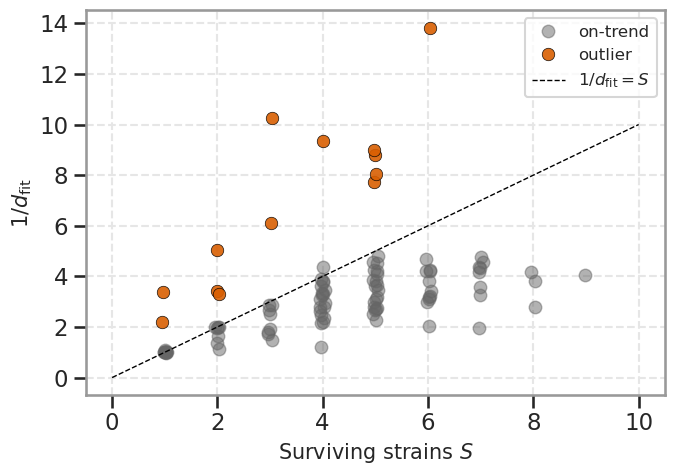

In [6]:
df = pd.DataFrame([{k: v for k, v in r.items()
                    if k not in ('u_ss', 'sparams', 'res')} for r in records])
df['residual'] = df['inv_d'] - df['S']
df['outlier'] = (0.9 * df['inv_d']) > df['S']

n_out = int(df['outlier'].sum())
print(f"Outliers (above 1/d = S line): {n_out} / {len(df)}")
print("\nOutlier repeats:", df.loc[df['outlier'], 'rep'].tolist())

# Recreate the notebook-06 scatter, highlighting the outliers
rng_j = np.random.default_rng(1)
jit = rng_j.uniform(-0.05, 0.05, size=len(df))
fig, ax = plt.subplots(figsize=(7, 5))
norm = ~df['outlier']
ax.plot(df['S'][norm] + jit[norm.values], df['inv_d'][norm], 'o',
        color='0.4', alpha=0.5, label='on-trend')
ax.plot(df['S'][df['outlier']] + jit[df['outlier'].values], df['inv_d'][df['outlier']],
        'o', color=colorTable['o'], alpha=0.9, markeredgecolor='k',
        markeredgewidth=0.5, label='outlier')
xs = np.array([0, df['S'].max() + 1])
ax.plot(xs, xs, '--', color='k', lw=1, label=r'$1/d_{\rm fit}=S$')
ax.set_xlabel("Surviving strains $S$")
ax.set_ylabel(r"$1/d_{\rm fit}$")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Why outliers sit above the line: the dispersion peak

`fit_d` is a monotone (decreasing) map from the target peak height to `d`. So whatever
makes a point an outlier must act through the **full-model dispersion peak height**: a
larger peak forces a smaller `d`, hence a larger `1/d_fit`. The plots below confirm that
`1/d_fit` is essentially a function of `peak_full`, and that outliers are exactly the
communities with anomalously large peaks for their `S`.

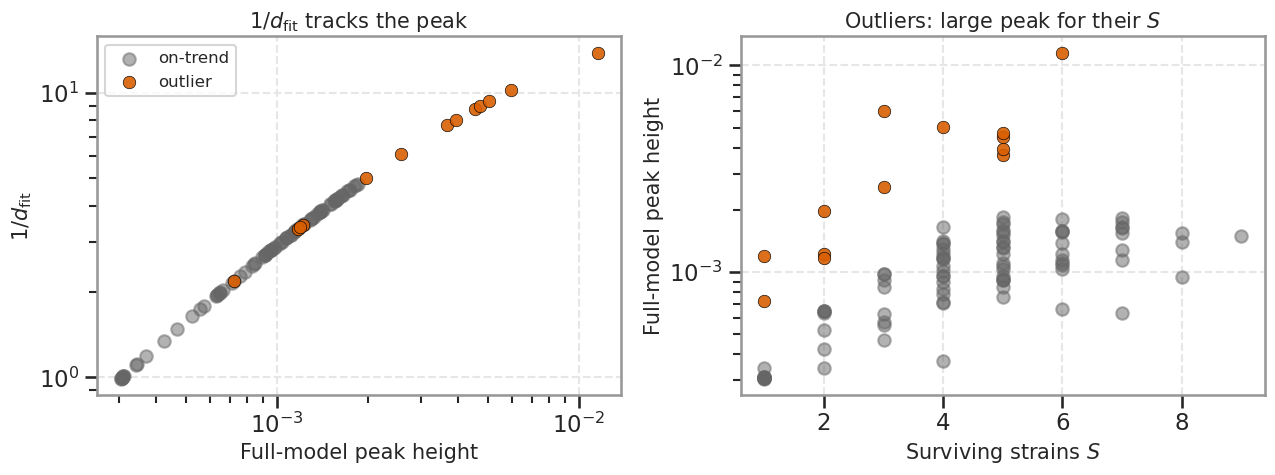

Mean full-model peak  — outliers: 0.00371   on-trend: 0.00103


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1/d_fit is a monotone function of the full-model peak (the fit's mechanism)
axes[0].scatter(df['peak_full'][~df['outlier']], df['inv_d'][~df['outlier']],
                color='0.4', alpha=0.5, label='on-trend')
axes[0].scatter(df['peak_full'][df['outlier']], df['inv_d'][df['outlier']],
                color=colorTable['o'], alpha=0.9, edgecolors='k', linewidths=0.5,
                label='outlier')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel("Full-model peak height")
axes[0].set_ylabel(r"$1/d_{\rm fit}$")
axes[0].set_title(r"$1/d_{\rm fit}$ tracks the peak")
axes[0].legend(fontsize=12)

# peak height vs S: outliers have a large peak for their S
axes[1].scatter(df['S'][~df['outlier']], df['peak_full'][~df['outlier']],
                color='0.4', alpha=0.5)
axes[1].scatter(df['S'][df['outlier']], df['peak_full'][df['outlier']],
                color=colorTable['o'], alpha=0.9, edgecolors='k', linewidths=0.5)
axes[1].set_yscale('log')
axes[1].set_xlabel("Surviving strains $S$")
axes[1].set_ylabel("Full-model peak height")
axes[1].set_title("Outliers: large peak for their $S$")
plt.tight_layout()
plt.show()

print("Mean full-model peak  — outliers: %.5f   on-trend: %.5f"
      % (df.loc[df['outlier'], 'peak_full'].mean(),
         df.loc[~df['outlier'], 'peak_full'].mean()))

## Cross-feeding structural diagnostics

The proximal cause is "a big peak for few strains". To see *why*, we dissect the
cross-feeding network of the surviving sub-community.

Recall the parameter regime: `linflux=1.0` and `l=0` elsewhere, so **all** byproduct
production comes from the (single) influx resource being 100% leaked and routed by `D`;
byproduct resources are then consumed with no further leakage. So the feedback loop is
*influx → byproduct resources (via `D`) → strains*. We measure how that feedback is
organised across the survivors.

For each community (survivors = strains above `STRAIN_CUTOFF_REL · max`):

- **n_crossR** — number of non-influx resources that are both produced and consumed by
  survivors (active feedback channels); and **crossR_per_S = n_crossR / S**.
- **cons_breadth / prod_breadth** — mean number of byproduct resources each survivor
  consumes / produces.
- **consumers_per_crossR** — mean number of survivors consuming each cross-fed resource
  (≈1 for a clean one-to-one loop; >1 means strains pile onto shared pools).
- **frac_self_loop** — fraction of survivors that consume a byproduct they themselves
  produce (self cross-feeding).
- **recycle_frac** — *the key diagnostic.* Of the influx each survivor leaks (its `D`
  weights over byproduct targets sum to 1), the fraction routed to a byproduct pool that
  **some survivor actually eats**. The minimal model has a single byproduct pool eaten at
  rate `d`, so it implicitly assumes `recycle_frac = 1` (all leaked carbon re-enters the
  loop). Leak routed to uneaten dead-end pools is lost to dilution and weakens the
  realised feedback. This is what lets an `S=1` community be an outlier: it equals the
  minimal model **only** when its strain re-eats 100% of its own leak.
- **dom_frac** — biomass fraction of the most abundant survivor; **eff_simpson** —
  inverse-Simpson effective strain number (evenness).

In [8]:
def crossfeed_metrics(u_ss, sparams, rel_cutoff=STRAIN_CUTOFF_REL):
    mi = sparams.micrm
    Ns, Nr = mi.Ns, mi.Nr
    c, D, K = mi.c, mi.D, mi.K
    strains = u_ss[:Ns]
    surv = strains > rel_cutoff * strains.max()
    surv_idx = np.where(surv)[0]
    S = len(surv_idx)

    influx = np.where(K > 0)[0]          # influx resource indices (one here)
    noninflux = (K == 0)

    # production routing: byproducts of the leaked influx resource(s)
    # produced[i, a] = strain i routes influx leakage to resource a
    produced = np.zeros((Ns, Nr), dtype=bool)
    for src in influx:
        produced |= (D[:, :, src] > 0)
    consumed = c > 0                      # consumed[i, a]

    prod_s = produced[surv_idx]           # (S, Nr)
    cons_s = consumed[surv_idx]

    prod_any = prod_s.any(axis=0)         # (Nr,)
    cons_any = cons_s.any(axis=0)
    crossfed = prod_any & cons_any & noninflux   # active feedback channels
    n_crossR = int(crossfed.sum())

    # breadth (over non-influx / cross-fed resources)
    cons_breadth = float((cons_s & noninflux).sum(axis=1).mean()) if S else np.nan
    prod_breadth = float((prod_s & noninflux).sum(axis=1).mean()) if S else np.nan

    # how many survivors consume each cross-fed resource
    if n_crossR > 0:
        consumers_per_crossR = float(cons_s[:, crossfed].sum(axis=0).mean())
    else:
        consumers_per_crossR = np.nan

    # self cross-feeding: produce and consume the same non-influx resource
    self_loop = ((prod_s & cons_s) & noninflux[None, :]).any(axis=1)
    frac_self_loop = float(self_loop.mean()) if S else np.nan

    # leak-recycling fraction: of the influx each survivor leaks (D weights sum to
    # 1 per strain), what fraction is routed to a byproduct resource that *some*
    # survivor eats? The minimal model implicitly assumes this is 1 (all leaked
    # carbon re-enters the loop). Lossy routing (leak to uneaten dead-end pools)
    # weakens the realised feedback.
    recyc = []
    for ii in surv_idx:
        for src in influx:
            w = D[ii, :, src]
            if w.sum() > 0:
                recyc.append(float(w[(cons_any) & noninflux].sum()))
    recycle_frac = float(np.mean(recyc)) if recyc else np.nan

    # abundance evenness
    p = strains[surv_idx] / strains[surv_idx].sum()
    dom_frac = float(p.max())
    eff_simpson = float(1.0 / np.sum(p**2))

    # strain->strain cross-feeding graph (i produces a resource j consumes)
    A = np.zeros((S, S), dtype=bool)
    for a, b in [(a, b) for a in range(S) for b in range(S)]:
        A[a, b] = bool((prod_s[a] & cons_s[b] & noninflux).any())
    off = A.copy(); np.fill_diagonal(off, False)
    n_edges = int(off.sum())
    reciprocity = float((off & off.T).sum() / n_edges) if n_edges else np.nan

    return dict(S=S, n_crossR=n_crossR, crossR_per_S=(n_crossR / S if S else np.nan),
                cons_breadth=cons_breadth, prod_breadth=prod_breadth,
                consumers_per_crossR=consumers_per_crossR,
                frac_self_loop=frac_self_loop, dom_frac=dom_frac,
                eff_simpson=eff_simpson, reciprocity=reciprocity,
                recycle_frac=recycle_frac)


metric_rows = []
for r in records:
    m = crossfeed_metrics(r['u_ss'], r['sparams'])
    m['rep'] = r['rep']
    metric_rows.append(m)

mdf = pd.DataFrame(metric_rows).set_index('rep')
df = df.set_index('rep').join(mdf[[col for col in mdf.columns if col != 'S']]).reset_index()
df.head()

,rep,S,d_fit,inv_d,peak_full,k_full,peak_mm,k_mm,residual,outlier,n_crossR,crossR_per_S,cons_breadth,prod_breadth,consumers_per_crossR,frac_self_loop,dom_frac,eff_simpson,reciprocity,recycle_frac
0,0,1,0.991103,1.008977,0.000311,40.142425,0.000311,40.142425,0.008977,False,2,2.0,4.0,2.0,1.000000,1.000000,1.000000,1.000000,NaN,1.000000
1,1,4,0.288518,3.465984,0.001235,19.556507,0.001235,19.556507,-0.534016,False,10,2.5,5.0,3.0,1.500000,0.250000,0.362148,3.548921,0.909091,0.846025
2,2,5,0.129465,7.724085,0.003670,10.642092,0.003670,11.247372,2.724085,True,12,2.4,4.4,3.2,1.666667,0.800000,0.354165,3.546081,0.666667,0.989221
3,3,5,0.289714,3.451682,0.001228,20.104964,0.001229,19.556507,-1.548318,False,8,1.6,2.8,2.0,1.250000,0.200000,0.262955,4.561716,0.545455,0.991516
4,4,3,0.350996,2.849035,0.000978,21.844361,0.000978,22.456980,-0.150965,False,6,2.0,5.0,2.0,1.000000,0.666667,0.624274,2.074507,1.000000,1.000000


### Outlier vs on-trend comparison

group           on-trend  outlier  ratio (out/on)
peak_full          0.001    0.004           3.613
recycle_frac       0.922    0.791           0.857
crossR_per_S       1.932    1.935           1.001
cons_breadth       4.380    4.496           1.027
frac_self_loop     0.594    0.745           1.255
dom_frac           0.523    0.565           1.081
eff_simpson        2.985    2.571           0.861
reciprocity        0.646    0.604           0.935


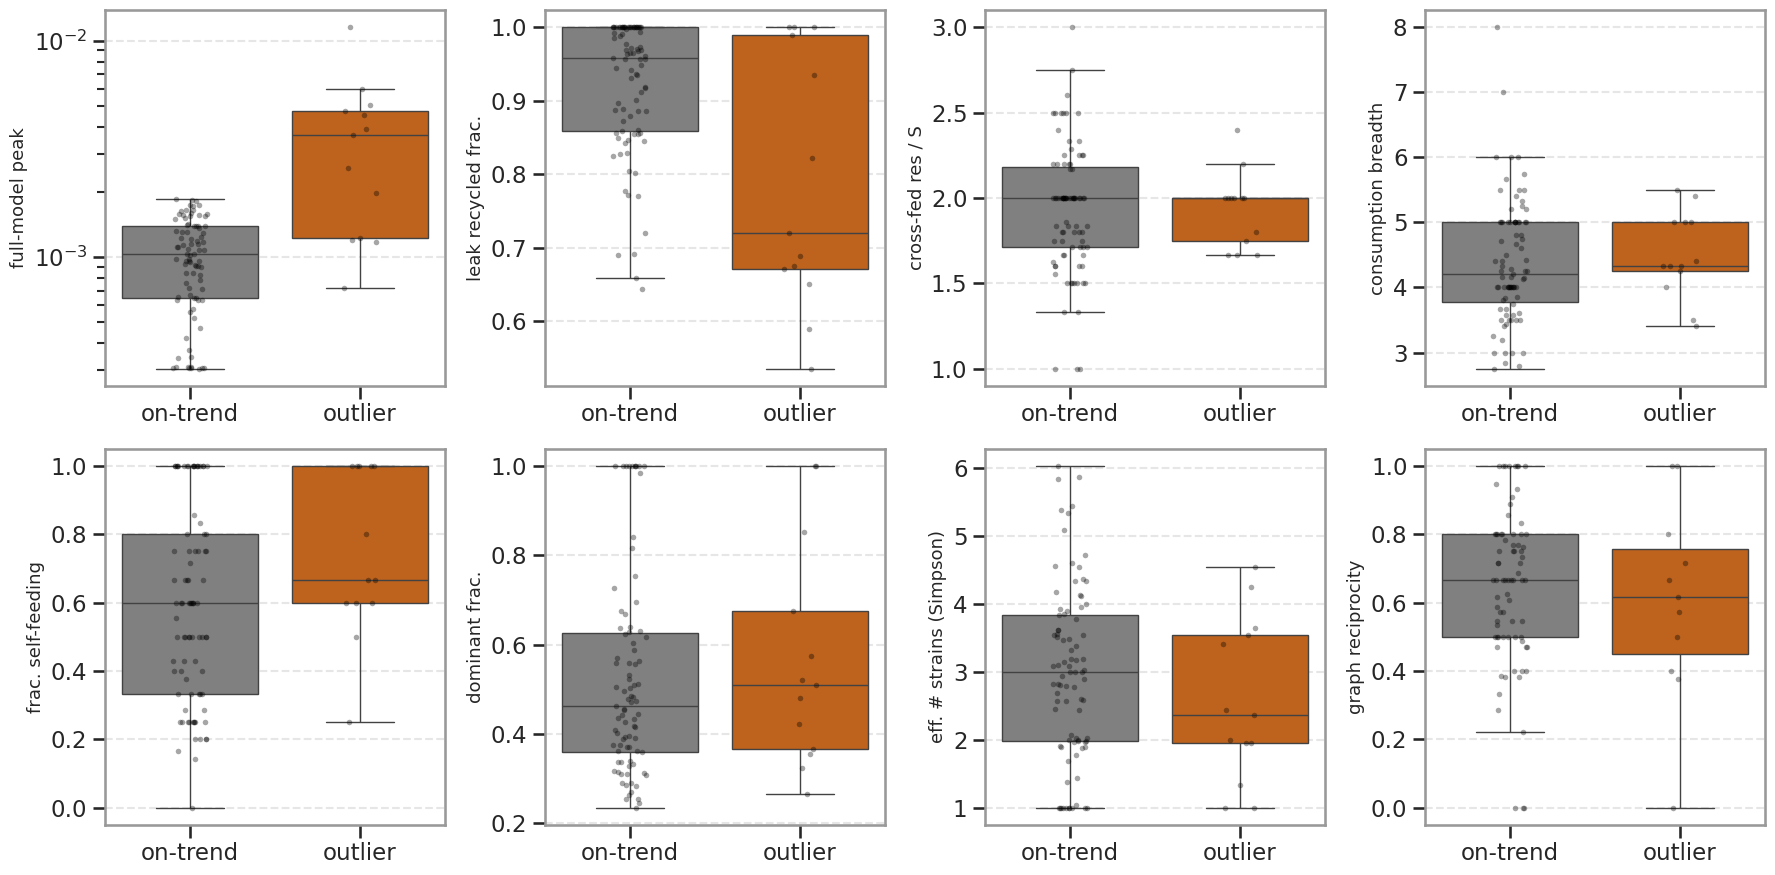

In [9]:
metrics = ['peak_full', 'recycle_frac', 'crossR_per_S', 'cons_breadth',
           'frac_self_loop', 'dom_frac', 'eff_simpson', 'reciprocity']
labels = {'peak_full': 'full-model peak', 'recycle_frac': 'leak recycled frac.',
          'crossR_per_S': 'cross-fed res / S',
          'cons_breadth': 'consumption breadth', 'consumers_per_crossR': 'consumers / cross-fed res',
          'frac_self_loop': 'frac. self-feeding', 'dom_frac': 'dominant frac.',
          'eff_simpson': 'eff. # strains (Simpson)', 'reciprocity': 'graph reciprocity'}

grp = df.assign(group=np.where(df['outlier'], 'outlier', 'on-trend'))
summary = grp.groupby('group')[metrics].mean().T
summary['ratio (out/on)'] = summary['outlier'] / summary['on-trend']
print(summary.to_string(float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
pal = {'on-trend': '0.5', 'outlier': colorTable['o']}
for ax, met in zip(axes.ravel(), metrics):
    sns.boxplot(data=grp, x='group', y=met, hue='group', palette=pal,
                order=['on-trend', 'outlier'], legend=False, ax=ax, fliersize=0)
    sns.stripplot(data=grp, x='group', y=met, order=['on-trend', 'outlier'],
                  color='k', alpha=0.35, size=4, ax=ax)
    ax.set_xlabel(''); ax.set_ylabel(labels[met], fontsize=13)
    if met == 'peak_full':
        ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Which structural feature tracks "outlierness"?

Scatter each structural metric against the continuous residual `1/d_fit - S` (positive =
above the line). Spearman correlations quantify which feature best explains the deviation
from the symmetric-loop prediction.

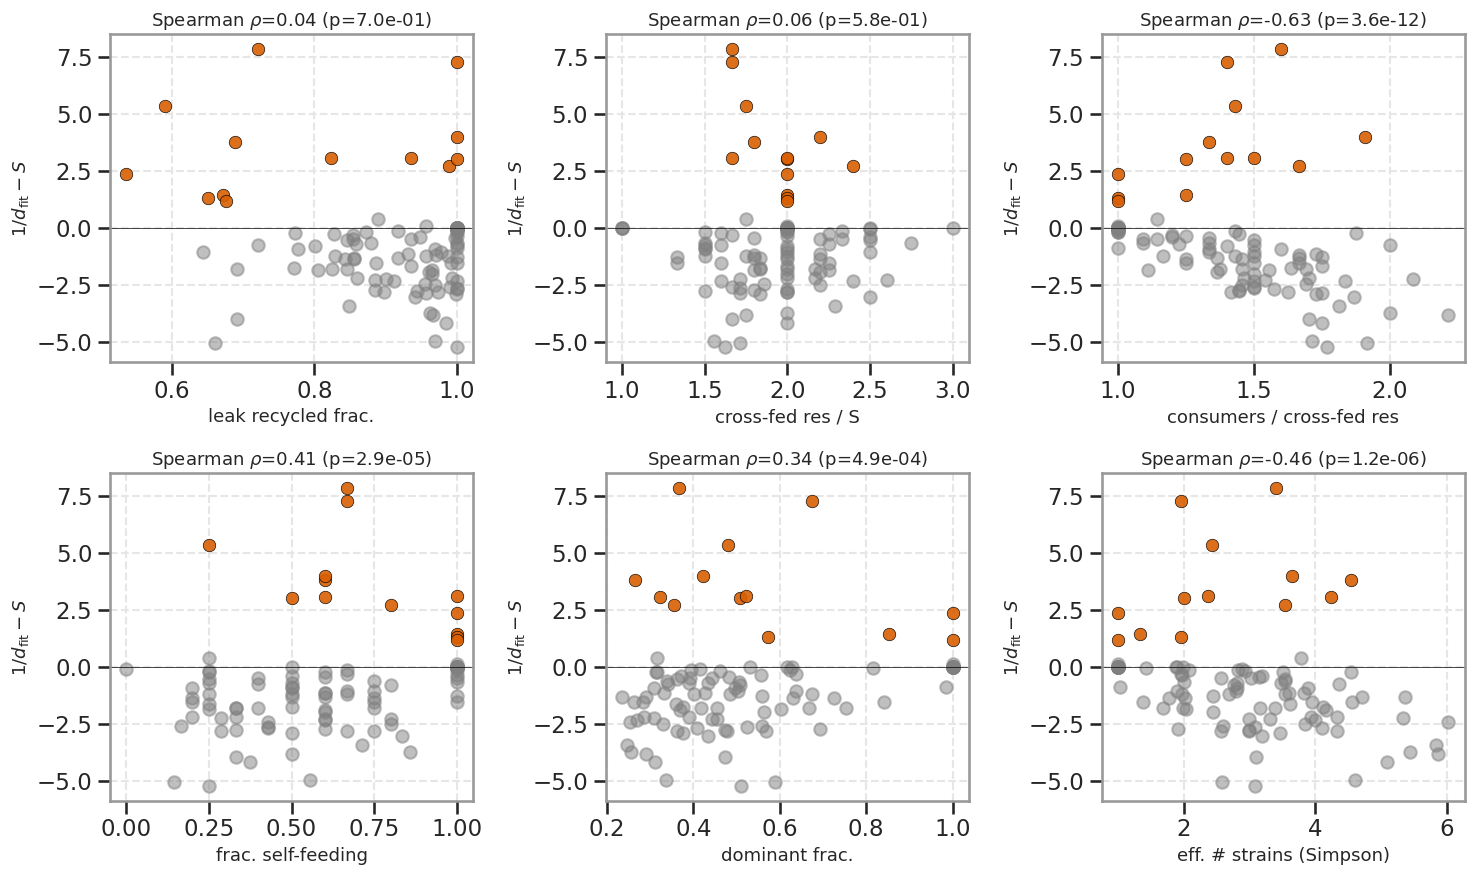

In [10]:
from scipy.stats import spearmanr

struct_metrics = ['recycle_frac', 'crossR_per_S', 'consumers_per_crossR',
                  'frac_self_loop', 'dom_frac', 'eff_simpson']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, met in zip(axes.ravel(), struct_metrics):
    rho, pval = spearmanr(df[met], df['residual'], nan_policy='omit')
    ax.scatter(df[met][~df['outlier']], df['residual'][~df['outlier']],
               color='0.5', alpha=0.5)
    ax.scatter(df[met][df['outlier']], df['residual'][df['outlier']],
               color=colorTable['o'], alpha=0.9, edgecolors='k', linewidths=0.5)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(labels[met], fontsize=13)
    ax.set_ylabel(r"$1/d_{\rm fit} - S$", fontsize=13)
    ax.set_title(f"Spearman $\\rho$={rho:.2f} (p={pval:.1e})", fontsize=13)
plt.tight_layout()
plt.show()

## The `S=1` paradox: lossy self-recycling

A single-strain community looks like it *should* be the minimal model exactly (one strain,
one influx resource, byproducts it re-eats). So how can an `S=1` community be an outlier?

The answer is `recycle_frac`. The sampler routes each strain's leaked influx to ~3
byproduct pools, but the strain eats any given resource only with probability `B/M=0.15`,
so it usually dumps part of its leak into pools it never eats. The minimal model has a
*single* byproduct pool eaten at rate `d` — it assumes `recycle_frac = 1`. An `S=1`
community equals the minimal model (`d = c = 1`, so `1/d_fit = 1`, on the line) **only**
when the strain re-eats 100% of its own leak. When it leaks into dead-end pools, the
realised feedback is weaker, the full-model Turing peak is larger, and the fit drops `d`
below 1 — lifting the point above the line. The table makes this monotone dependence
explicit.

 rep  recycle_frac  inv_d  peak_full  outlier
  91         0.536  3.370      0.001     True
  85         0.675  2.189      0.001     True
  40         0.956  1.107      0.000    False
  17         1.000  0.998      0.000    False
  49         1.000  0.989      0.000    False
  56         1.000  0.995      0.000    False
  80         1.000  0.997      0.000    False
   0         1.000  1.009      0.000    False
  86         1.000  0.999      0.000    False
  89         1.000  1.008      0.000    False
  97         1.000  0.994      0.000    False
  99         1.000  1.013      0.000    False


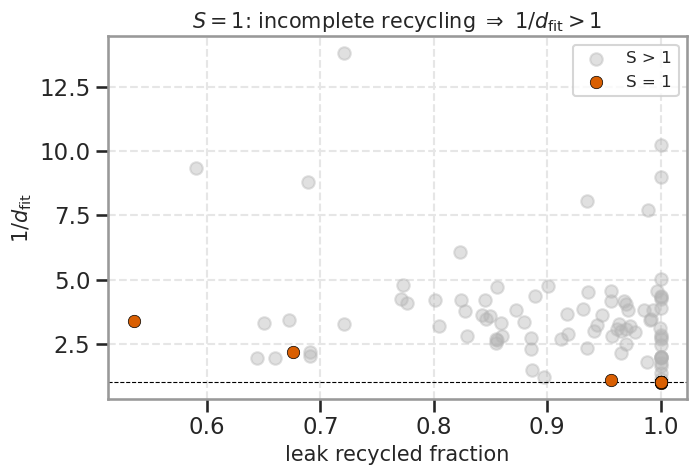

In [11]:
s1 = df[df['S'] == 1].sort_values('recycle_frac')
print(s1[['rep', 'recycle_frac', 'inv_d', 'peak_full', 'outlier']].to_string(
    index=False, float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['recycle_frac'][df['S'] > 1], df['inv_d'][df['S'] > 1],
           color='0.7', alpha=0.4, label='S > 1')
ax.scatter(s1['recycle_frac'], s1['inv_d'], color=colorTable['o'], s=80,
           edgecolors='k', linewidths=0.5, label='S = 1', zorder=3)
ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.set_xlabel("leak recycled fraction")
ax.set_ylabel(r"$1/d_{\rm fit}$")
ax.set_title(r"$S=1$: incomplete recycling $\Rightarrow$ $1/d_{\rm fit} > 1$")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Case studies of extreme outliers

We zoom in on the most extreme outliers and contrast them with a typical on-trend
community of the same `S`. For each we (a) overlay the full-model and fitted minimal-model
dispersions and (b) draw the survivor cross-feeding graph (nodes = surviving strains, an
arrow `i→j` means a byproduct of `i` is eaten by `j`; self-loops drawn as a ring).

Case-study reps: [69, 68, 46, 85, 91]


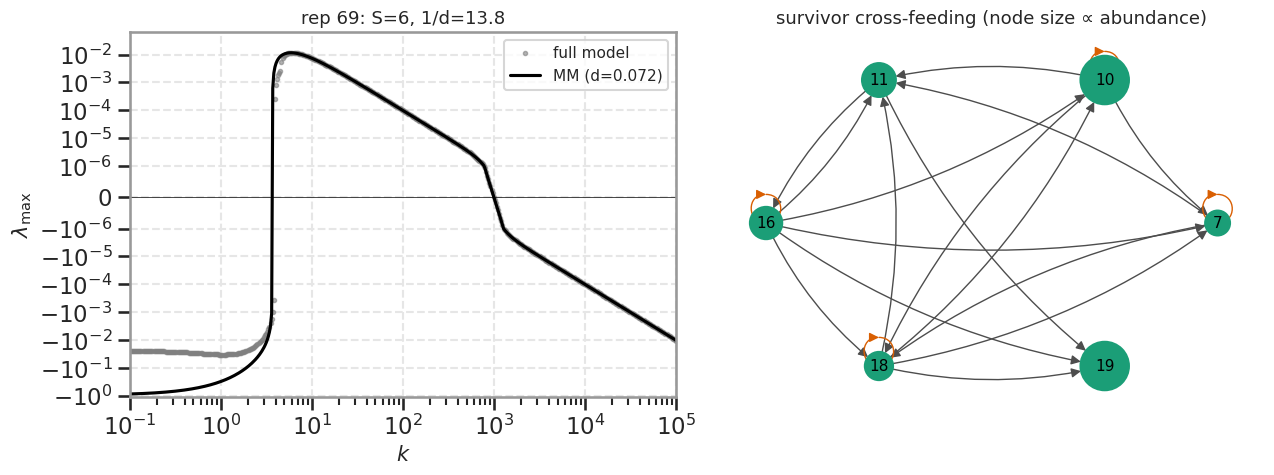

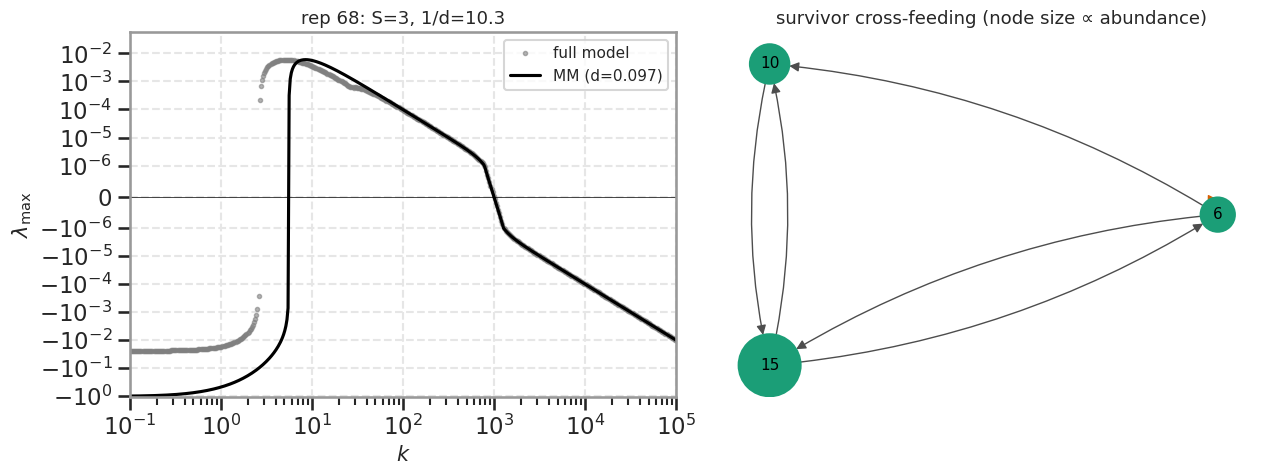

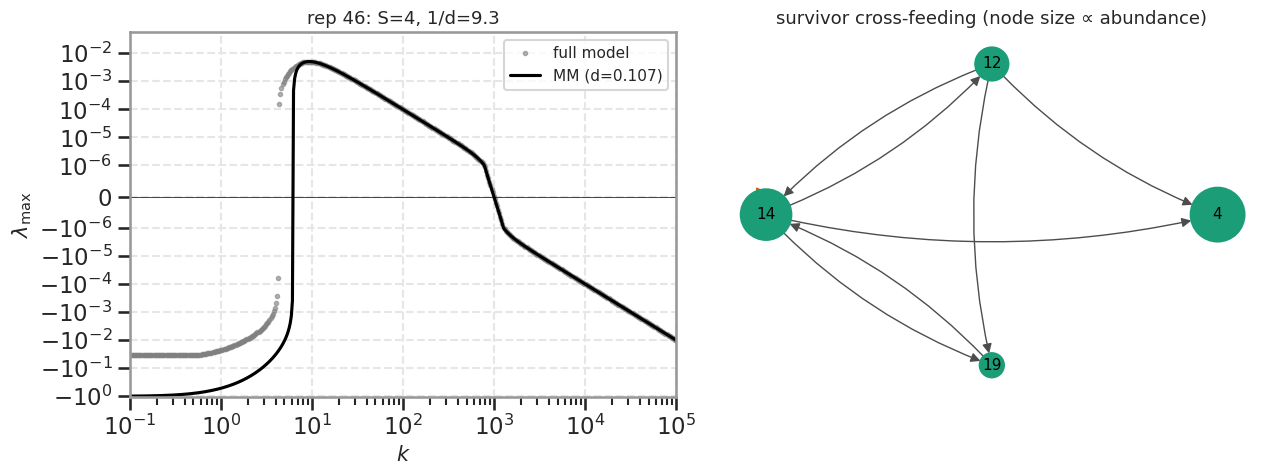

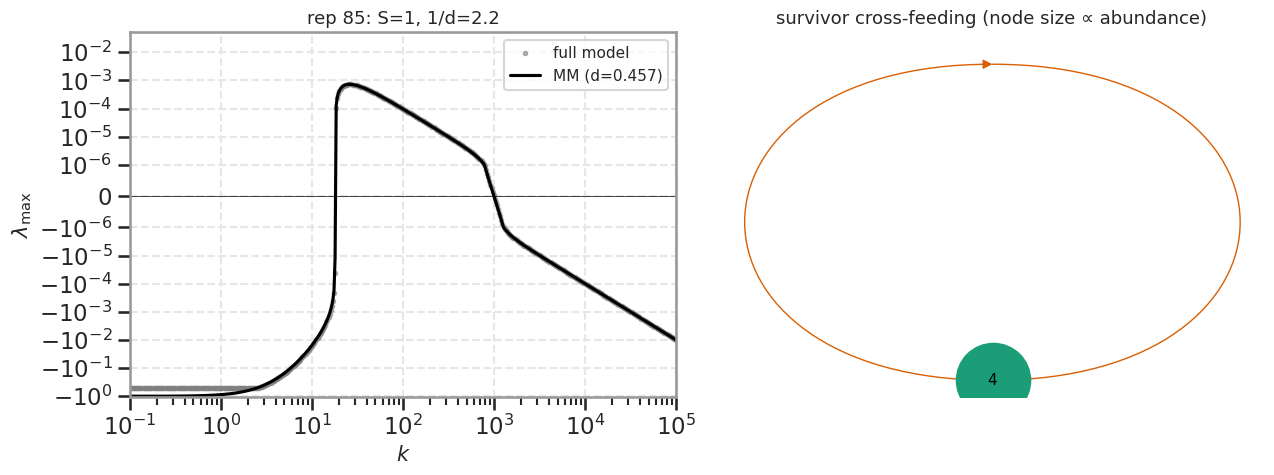

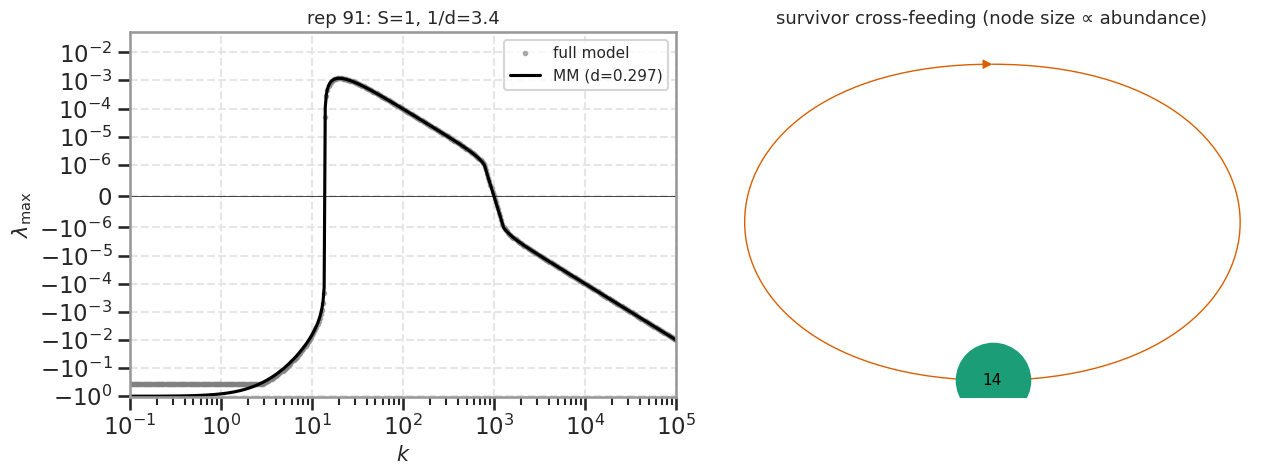

In [12]:
def draw_crossfeed_graph(ax, u_ss, sparams, title='', rel_cutoff=STRAIN_CUTOFF_REL):
    mi = sparams.micrm
    Ns, Nr = mi.Ns, mi.Nr
    c, D, K = mi.c, mi.D, mi.K
    strains = u_ss[:Ns]
    surv_idx = np.where(strains > rel_cutoff * strains.max())[0]
    influx = np.where(K > 0)[0]
    noninflux = (K == 0)
    produced = np.zeros((Ns, Nr), dtype=bool)
    for src in influx:
        produced |= (D[:, :, src] > 0)
    consumed = c > 0

    G = nx.MultiDiGraph()
    for n in surv_idx:
        G.add_node(int(n))
    for a in surv_idx:
        for b in surv_idx:
            shared = produced[a] & consumed[b] & noninflux
            if shared.any():
                G.add_edge(int(a), int(b))

    pos = nx.circular_layout(G) if G.number_of_nodes() > 1 else {int(surv_idx[0]): (0, 0)}
    sizes = 300 + 2500 * (strains[surv_idx] / strains[surv_idx].sum())
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=[colorTable['g']], ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=11, ax=ax)
    straight = [(u, v) for u, v in G.edges() if u != v]
    selfl = [(u, v) for u, v in G.edges() if u == v]
    nx.draw_networkx_edges(G, pos, edgelist=straight, ax=ax, arrowsize=14,
                           connectionstyle='arc3,rad=0.12', edge_color='0.3',
                           node_size=sizes)
    if selfl:
        nx.draw_networkx_edges(G, pos, edgelist=selfl, ax=ax, arrowsize=14,
                               connectionstyle='arc3,rad=0.4', edge_color=colorTable['o'])
    ax.set_title(title, fontsize=13)
    ax.axis('off')


def overlay_dispersion(ax, rec, title=''):
    res = rec['res']
    ax.plot(res.ks, res.mrls, 'o', color='gray', ms=3, alpha=0.6, label='full model')
    if not np.isnan(rec['d_fit']):
        res_mm = mm_scan(rec['d_fit'])
        ax.plot(res_mm.ks, res_mm.mrls, '-', color='k',
                label=f"MM (d={rec['d_fit']:.3f})")
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=1e-6)
    ax.set_xlim(1e-1, 1e5)
    ax.set_xlabel('$k$'); ax.set_ylabel(r'$\lambda_{\max}$')
    ax.legend(fontsize=11)
    ax.set_title(title, fontsize=13)


rec_by_rep = {r['rep']: r for r in records}

# most extreme outliers by residual, plus the S=1 outliers
out_reps = df.loc[df['outlier']].sort_values('residual', ascending=False)
top = out_reps['rep'].tolist()[:3]
s1_out = df.loc[df['outlier'] & (df['S'] == 1), 'rep'].tolist()
case_reps = top + [r for r in s1_out if r not in top][:2]
print("Case-study reps:", case_reps)

for rp in case_reps:
    rec = rec_by_rep[rp]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    overlay_dispersion(axes[0], rec,
        title=f"rep {rp}: S={int(df.loc[df['rep']==rp,'S'].iloc[0])}, "
              f"1/d={df.loc[df['rep']==rp,'inv_d'].values[0]:.1f}")
    draw_crossfeed_graph(axes[1], rec['u_ss'], rec['sparams'],
                         title='survivor cross-feeding (node size ∝ abundance)')
    plt.tight_layout()
    plt.show()

### Contrast: a typical on-trend community

For comparison, the same two panels for an on-trend community with several surviving
strains (a closer-to-symmetric loop).

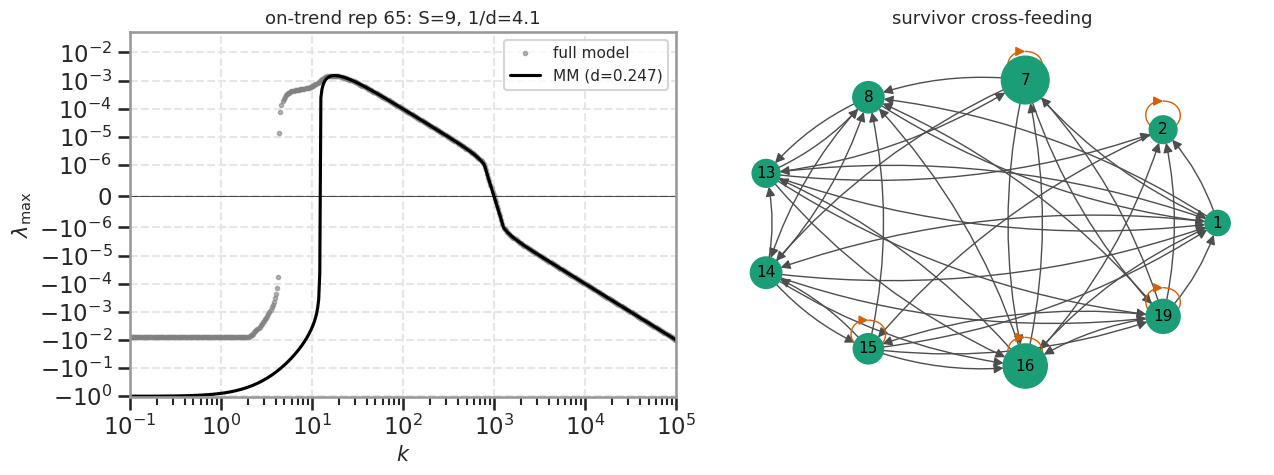

In [13]:
on_trend = df.loc[~df['outlier']].sort_values('S', ascending=False)
ref_rep = int(on_trend['rep'].iloc[0])
rec = rec_by_rep[ref_rep]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
overlay_dispersion(axes[0], rec,
    title=f"on-trend rep {ref_rep}: S={int(df.loc[df['rep']==ref_rep,'S'].iloc[0])}, "
          f"1/d={df.loc[df['rep']==ref_rep,'inv_d'].values[0]:.1f}")
draw_crossfeed_graph(axes[1], rec['u_ss'], rec['sparams'],
                     title='survivor cross-feeding')
plt.tight_layout()
plt.show()

## Toy model: a *leaky* minimal model

The mechanism above predicts a concrete, minimal-model-analogous toy. Take the standard
minimal model but add **one dead-end byproduct resource**: the strain leaks a fraction
`f` of its consumed influx into a recycled pool it eats (at rate `c`), and the remaining
`1-f` into a sink pool **no one eats** (only diluted). `f = 1` is exactly the closed
minimal model; `f < 1` is the lossy case the outliers live in.

We then *fit a closed minimal model* (the `f = 1` form, free `d`) to the leaky model's
dispersion peak — exactly the procedure applied to the sampled communities — and ask how
the recovered `d_fit` depends on `f`. The prediction is `d_fit · S ≈ f`; here `S = 1`, so
`d_fit ≈ f`.

In [14]:
from ssmc.params import MiCRMParams, SpatialMiCRMParams

def leaky_mm(f, c=1.0, d=1.0, K=K_FIXED, m=1.0, r=1.0, DN=1e-12, DI=1.0, DR=1.0):
    """Minimal model + one dead-end byproduct pool.

    Resources: 0 = influx, 1 = recycled byproduct (eaten at rate d),
    2 = sink (eaten by no one). A fraction f of the leaked influx is routed to
    the recycled pool, 1-f to the sink. f=1 recovers the closed minimal model.
    """
    D = np.zeros((1, 3, 3))
    D[0, 1, 0] = f
    D[0, 2, 0] = 1.0 - f
    micrm = MiCRMParams(
        g=np.array([1.0]), w=np.ones(3), m=np.array([m]),
        K=np.array([K, 0.0, 0.0]), r=np.array([r, r, r]),
        l=np.array([[1.0, 0.0, 0.0]]),     # linflux=1 on influx; no leak on byproducts
        c=np.array([[c, d, 0.0]]),         # eat influx at c, recycled at d, sink not eaten
        D=D)
    return SpatialMiCRMParams(micrm=micrm, Ds=np.array([DN, DI, DR, DR]))


f_grid = np.linspace(0.3, 1.0, 22)
toy_dfit = []
for f in f_grid:
    sp = leaky_mm(f)
    u_ss, ok = solve_steady_state(sp.micrm, np.array([1.0, 0.0, 0.0, 0.0]),
                                  t_max=5e3, rtol=1e-10, atol=1e-12, ss_tol=1e-9)
    res = scan_k(sp, u_ss, lsks)
    toy_dfit.append(fit_d(res.max_mrl))     # fit the CLOSED minimal model
toy_dfit = np.array(toy_dfit)

print(" f      d_fit   d_fit/f")
for f, dd in zip(f_grid, toy_dfit):
    print(f" {f:.3f}  {dd:.3f}   {dd/f:.3f}")

 f      d_fit   d_fit/f
 0.300  0.112   0.374
 0.333  0.132   0.395
 0.367  0.153   0.418
 0.400  0.177   0.442
 0.433  0.203   0.469
 0.467  0.231   0.496
 0.500  0.262   0.524
 0.533  0.295   0.553
 0.567  0.330   0.583
 0.600  0.368   0.613
 0.633  0.408   0.644
 0.667  0.450   0.675
 0.700  0.494   0.706
 0.733  0.541   0.738
 0.767  0.591   0.770
 0.800  0.642   0.803
 0.833  0.696   0.835
 0.867  0.752   0.868
 0.900  0.810   0.901
 0.933  0.871   0.934
 0.967  0.935   0.967
 1.000  1.000   1.000


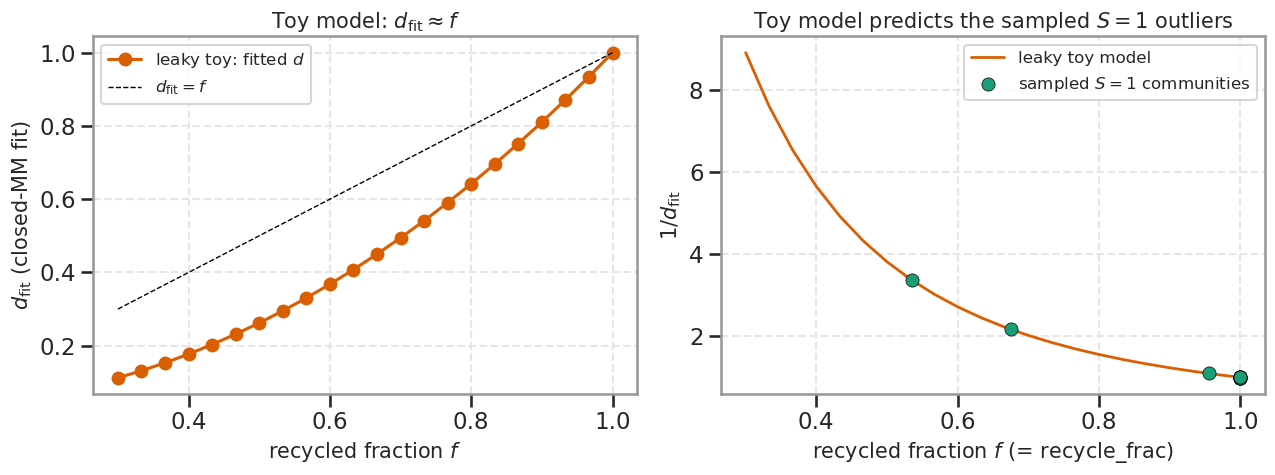

rep 91: recycle_frac=0.54  sampled 1/d_fit=3.37  toy-model 1/d_fit=3.36
rep 85: recycle_frac=0.68  sampled 1/d_fit=2.19  toy-model 1/d_fit=2.17


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# d_fit vs f: prediction d_fit = f
axes[0].plot(f_grid, toy_dfit, 'o-', color=colorTable['o'], label=r'leaky toy: fitted $d$')
axes[0].plot([0.3, 1.0], [0.3, 1.0], 'k--', lw=1, label=r'$d_{\rm fit}=f$')
axes[0].set_xlabel("recycled fraction $f$")
axes[0].set_ylabel(r"$d_{\rm fit}$ (closed-MM fit)")
axes[0].set_title(r"Toy model: $d_{\rm fit}\approx f$")
axes[0].legend(fontsize=12)

# 1/d_fit vs recycle fraction: toy curve vs the sampled S=1 outliers
axes[1].plot(f_grid, 1.0 / toy_dfit, '-', color=colorTable['o'], lw=2,
             label='leaky toy model')
s1 = df[df['S'] == 1]
axes[1].scatter(s1['recycle_frac'], s1['inv_d'], s=90, color=colorTable['g'],
                edgecolors='k', linewidths=0.5, zorder=3, label='sampled $S=1$ communities')
axes[1].set_xlabel("recycled fraction $f$ (= recycle_frac)")
axes[1].set_ylabel(r"$1/d_{\rm fit}$")
axes[1].set_title(r"Toy model predicts the sampled $S=1$ outliers")
axes[1].legend(fontsize=12)
plt.tight_layout()
plt.show()

# quantitative check at the two S=1 outliers
for rp in [91, 85]:
    fr = float(df.loc[df['rep'] == rp, 'recycle_frac'].iloc[0])
    invd = float(df.loc[df['rep'] == rp, 'inv_d'].iloc[0])
    toy_pred = float(1.0 / np.interp(fr, f_grid, toy_dfit))
    print(f"rep {rp}: recycle_frac={fr:.2f}  sampled 1/d_fit={invd:.2f}  "
          f"toy-model 1/d_fit={toy_pred:.2f}")

## Conclusion

The outliers are **not** an artifact of the survivor cutoff (no sub-threshold strains hide
below it) and **not** a fitting failure. They are real communities whose full-model Turing
peak is anomalously large for their surviving-strain count `S`. Because `fit_d` inverts a
monotone peak-vs-`d` curve, a large peak is matched only by a small `d`, placing the point
above the `1/d_fit = S` line.

The mechanism is **lossy recycling of leaked carbon.** In this regime (`linflux=1`, `l=0`
elsewhere) growth is obligately cross-fed: a strain assimilates *nothing* from the influx
resource — it leaks 100% of it into byproduct pools and grows only on byproducts it (or a
neighbour) re-eats. The symmetric-loop theory assumes the loop is *closed*: every unit of
leaked carbon is reconsumed, so `S` strains each recycle their share and `d_fit · S = 1`.
The minimal model inherits this assumption — its single byproduct pool is eaten at rate
`d`, i.e. `recycle_frac = 1` by construction.

Outliers break the closure. The sampler routes each strain's leak across ~3 byproduct
pools, but a strain eats any given resource with probability only `B/M = 0.15`, so a
sizeable fraction of leaked carbon lands in **dead-end pools nobody eats** and is lost to
dilution. Lower `recycle_frac` ⇒ weaker realised feedback ⇒ larger Turing peak ⇒ smaller
`d_fit` ⇒ point above the line. The `S=1` analysis makes this unambiguous: a single-strain
community equals the minimal model (`1/d_fit ≈ 1`) *only* when it re-eats all its own leak;
as `recycle_frac` drops to ~0.5, `1/d_fit` climbs to ~3. The aggregate structural metrics
(fewer active cross-fed pools `n_crossR`, more uneven abundances, more self-feeding) are
all facets of the same thing — the realised cross-feeding loop is leakier and less even
than the closed symmetric ring the theory assumes.

**Caveat on direction.** Across the full set, `d_fit · S` is *not* tightly bounded below 1:
its mean is ≈1.4 and the *majority* of communities sit at `d_fit · S > 1` (below the line),
because imperfect, uneven loops are generically *less* coherently unstable than the ideal
symmetric ring and so fit a *larger* `d`. The symmetric loop (`d_fit · S = 1`) is better
read as the **maximally-recycling boundary**: communities scatter to `d_fit · S > 1` when
the loop is incoherent, and the handful that overshoot to `d_fit · S < 1` (the above-line
outliers analysed here) are those with an unusually strong standing-byproduct gradient
from lossy/concentrated recycling. Which tail one calls the "outlier" depends on whether
the theory is read as the equality `d_fit · S = 1` or the bound `d_fit · S < 1`.

**A toy model analogous to the symmetric loop.** Add one *dead-end* byproduct resource to
the minimal model: a strain leaks a fraction `f` of its influx into the recycled pool
(eaten at rate `c`) and `1−f` into a sink pool that no one eats (only diluted). `f = 1`
recovers the minimal model exactly. For `f < 1`, fitting a *closed* minimal model to the
dispersion returns `d_fit < c` — reproducing the `S=1` outliers analytically. The
`S`-strain version is the symmetric ring with the same per-strain leak loss `f`, giving
`d_fit · S ≈ f` and recovering the closed-loop result as `f → 1`.